# Verde River EDA

In [8]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [4]:
df = pd.read_csv("../Data/FormattedData/Combined_Monthly_Data.csv")
season_length = 12
test_size = int(8.5 * season_length) # Set aside the last 8.5 years as our ultimate testing set.
df_train = df[:-test_size].copy()
df_test = df[-test_size:].copy()

Plotting upstream and downstream flow over time.

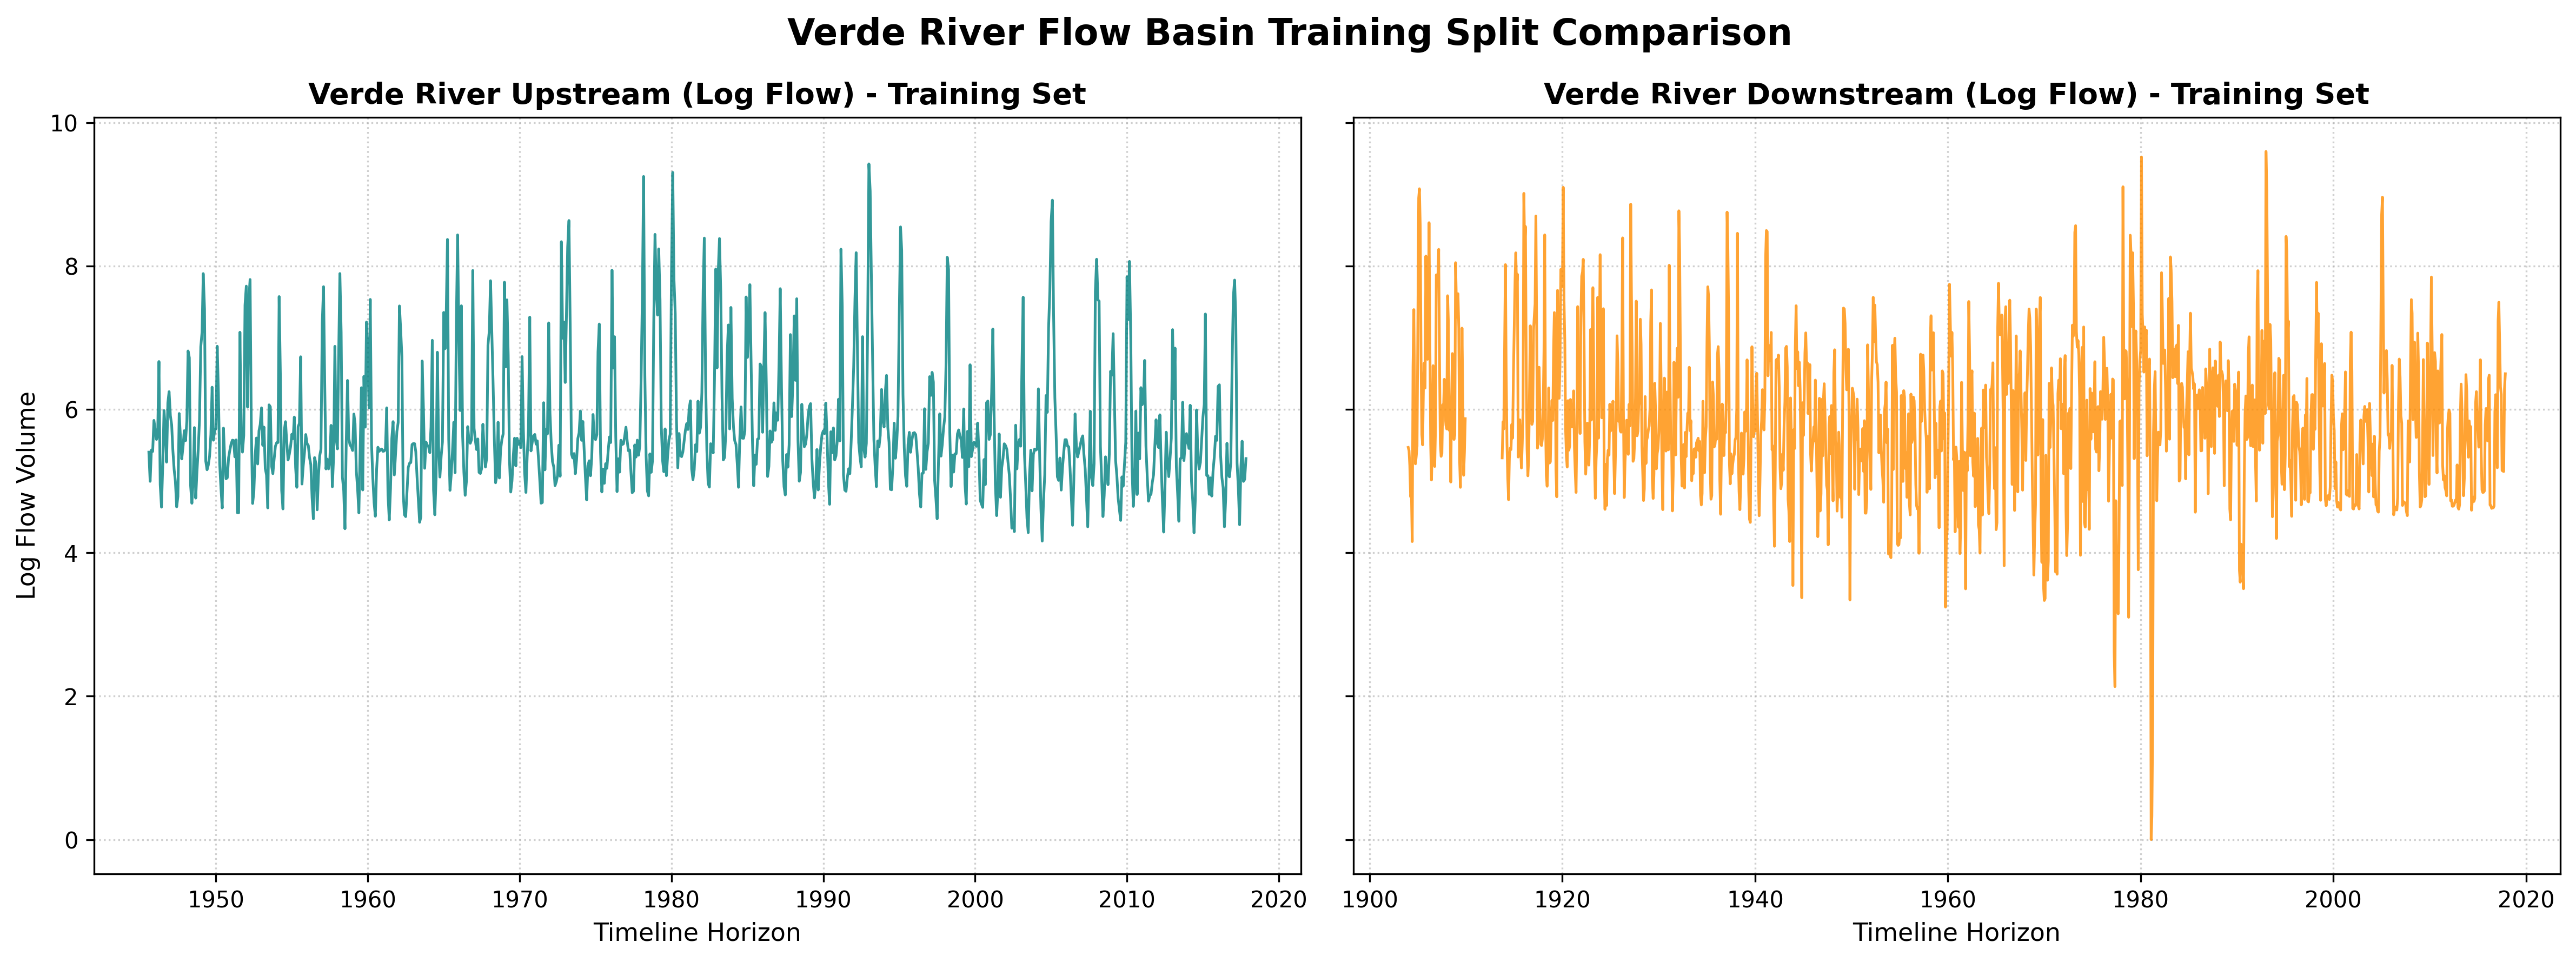

In [6]:
# 1. Parse and format timestamps in training data
df_train['Time'] = pd.to_datetime(df_train['Time'])

# 2. Create a 1-row, 2-column subplot grid with a shared Y-axis
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300, sharey=True)

# 3. Plot Upstream Flow (Left Panel)
axes[0].plot(
    df_train['Time'], df_train['log_flow_verde_upstream'], 
    color='teal', alpha=0.8, linewidth=1.2
)
axes[0].set_title('Verde River Upstream (Log Flow) - Training Set', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Timeline Horizon', fontsize=11)
axes[0].set_ylabel('Log Flow Volume', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 4. Plot Downstream Flow (Right Panel)
axes[1].plot(
    df_train['Time'], df_train['log_flow_verde_downstream'], 
    color='darkorange', alpha=0.8, linewidth=1.2
)
axes[1].set_title('Verde River Downstream (Log Flow) - Training Set', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Timeline Horizon', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

# 5. Global title adjustments and layout optimization
plt.suptitle('Verde River Flow Basin Training Split Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

# Save the crisp 300 DPI high-resolution image
plt.savefig('../Output/verde_training_flow_side_by_side.png', dpi=300, bbox_inches='tight')
plt.show()

Now we plot Verde downstream data against the features we intend to use.

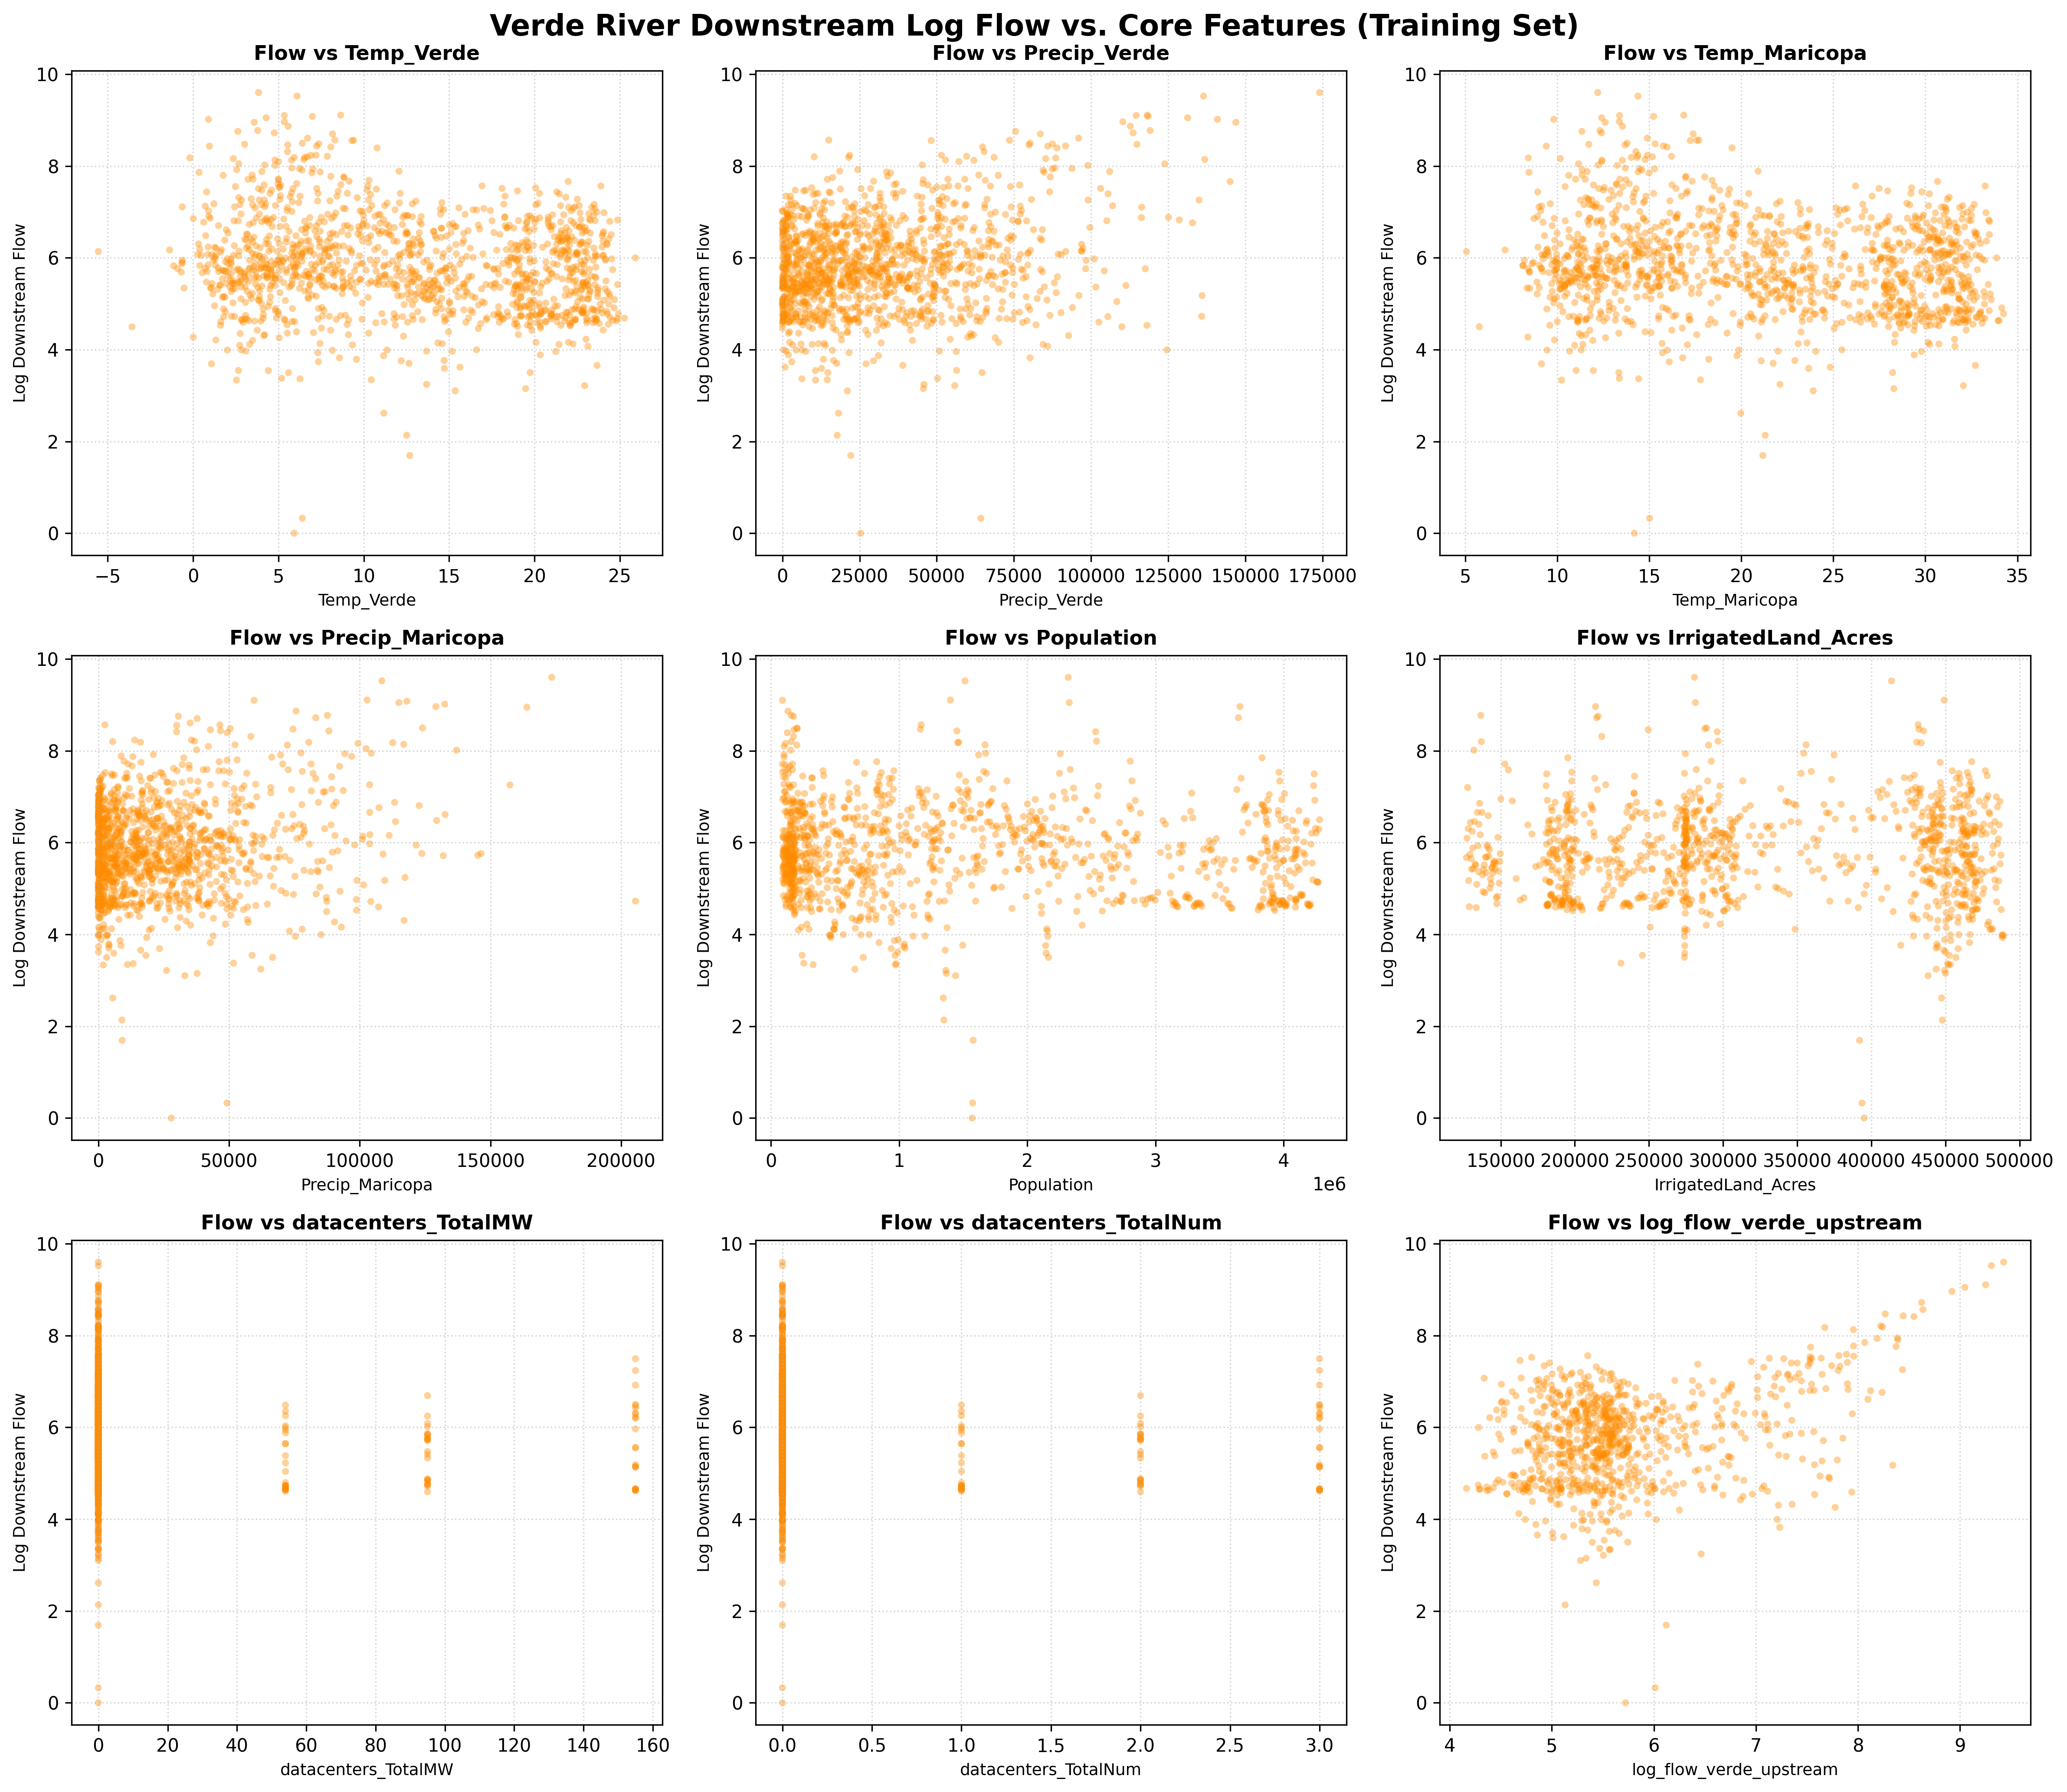

In [10]:
# 1. Parse and format timestamps in training data 
df_train['Time'] = pd.to_datetime(df_train['Time'])

# Define Verde downstream core features
verde_core_features = [
    "Temp_Verde",
    "Precip_Verde",
    "Temp_Maricopa",
    "Precip_Maricopa",
    "Population",
    "IrrigatedLand_Acres",
    "datacenters_TotalMW",
    "datacenters_TotalNum",
    "log_flow_verde_upstream"
]
target = "log_flow_verde_downstream"

# 2. Dynamic canvas dimensions setup for a 3x3 grid matrix
num_features = len(verde_core_features)
ncols = 3
nrows = math.ceil(num_features / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 14), dpi=300)
axes = axes.flatten()  # Flatten the 2D array to iterate over it with a single loop

# 3. Populate subplots looping through core features
for i, feature in enumerate(verde_core_features):
    ax = axes[i]
    
    # Render scattered nodes utilizing alpha configurations to reveal density concentrations
    ax.scatter(df_train[feature], df_train[target], color="darkorange", alpha=0.4, edgecolors="none", s=15)
    
    # Style and format each independent coordinate frame
    ax.set_title(f"Flow vs {feature}", fontsize=11, fontweight="bold")
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel("Log Downstream Flow", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

# Clear any unused grid cells if the array size varies from a perfect multiple of 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 4. Finalize canvas spacing adjustments and export
plt.suptitle("Verde River Downstream Log Flow vs. Core Features (Training Set)", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()

# Save the high-resolution clean PNG file
plt.savefig("../Output/verde_downstream_vs_features_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

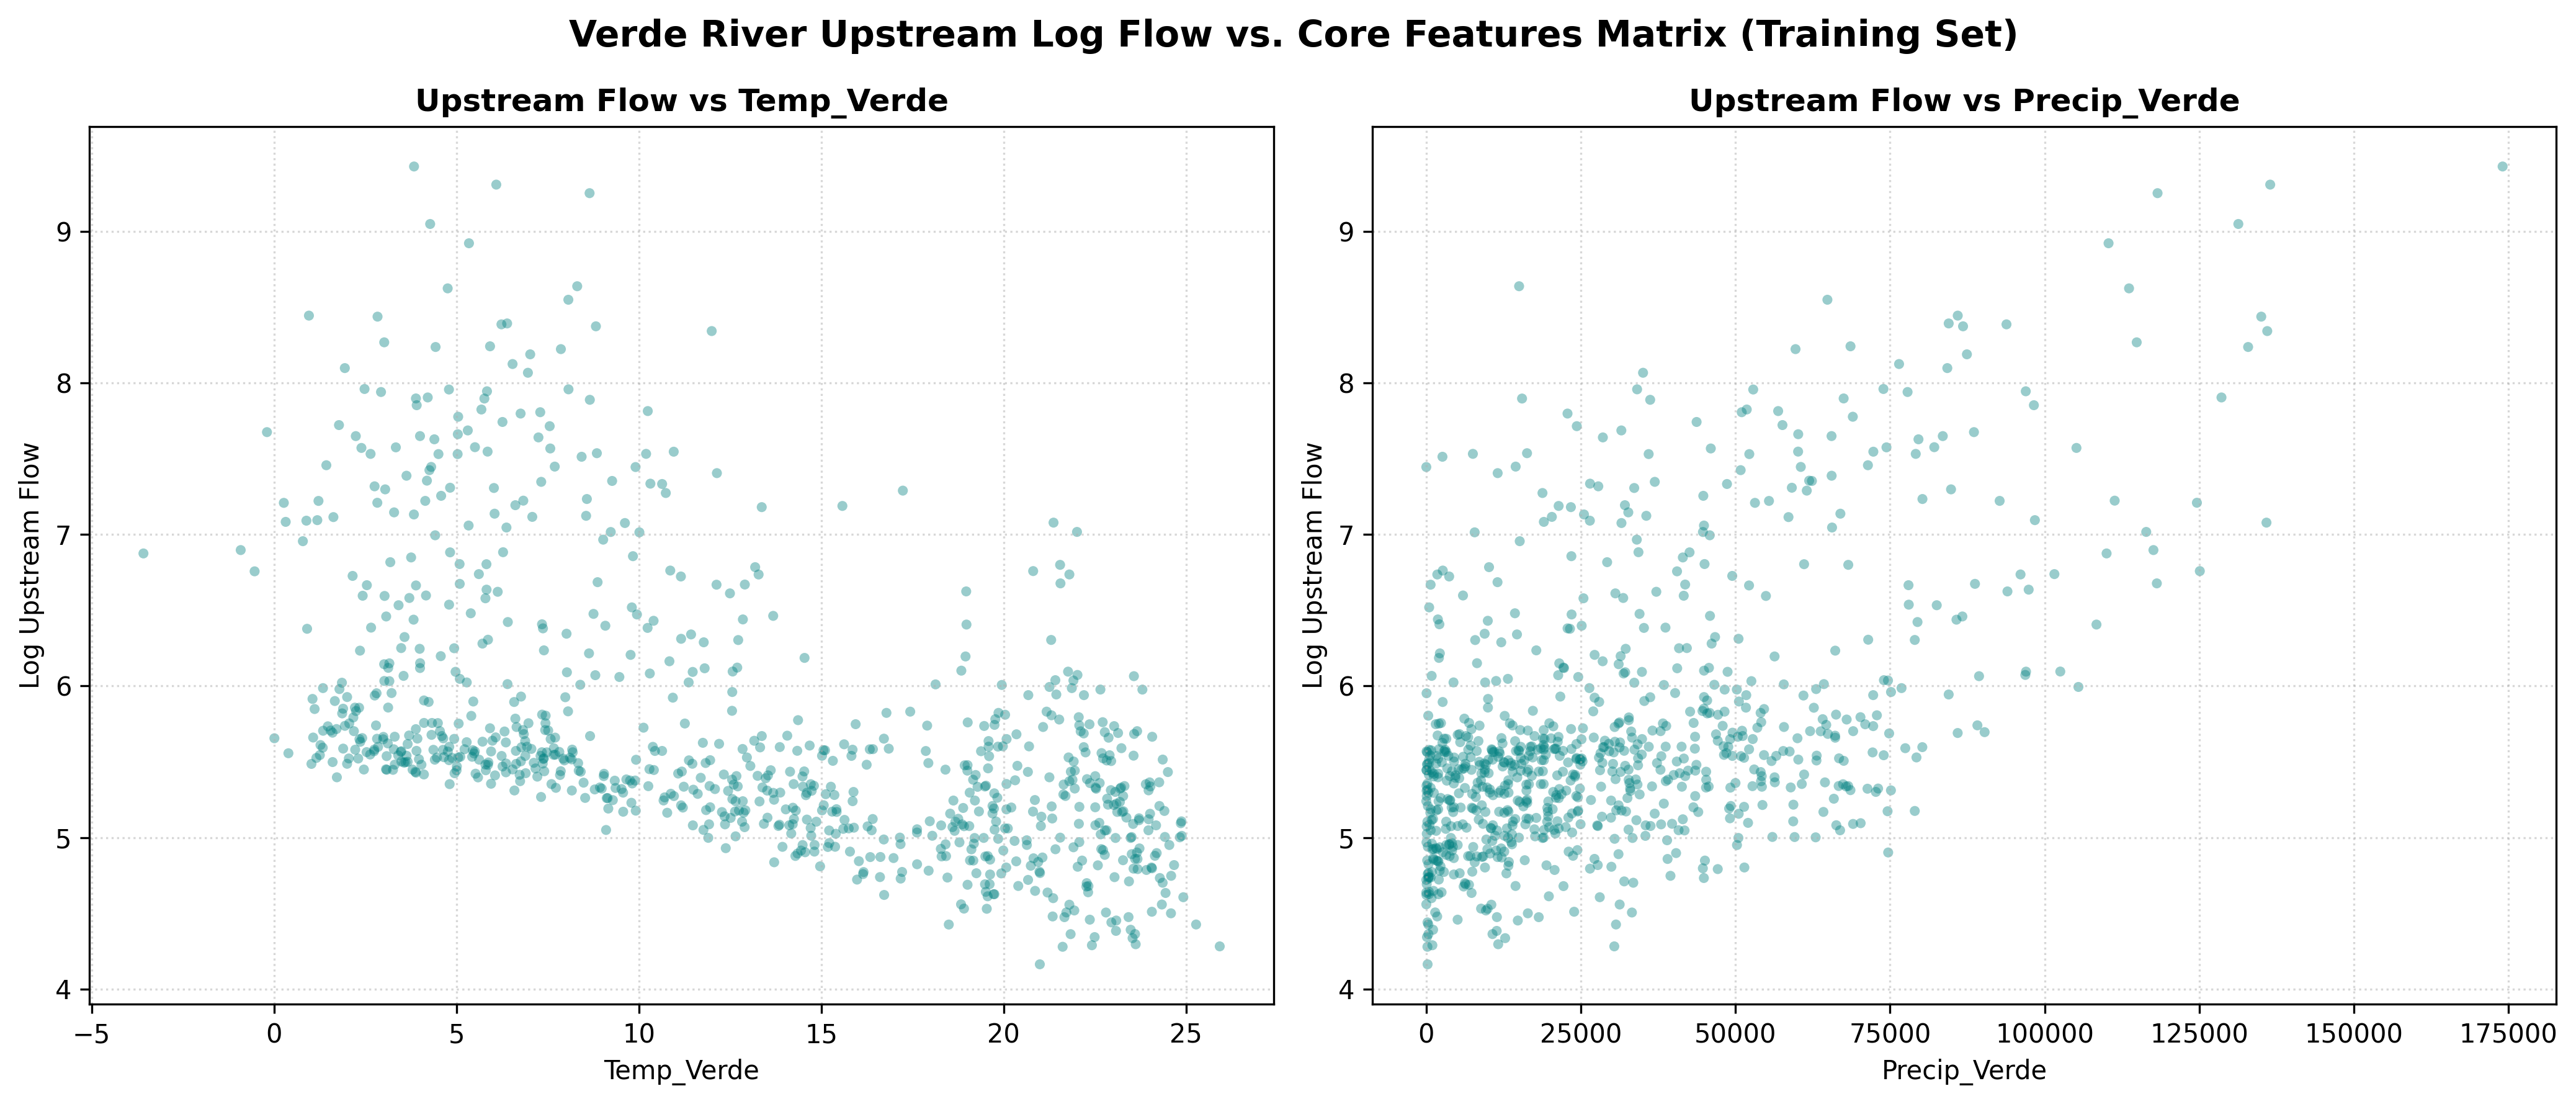

In [11]:
# 1. Parse and format timestamps in training data
df_train['Time'] = pd.to_datetime(df_train['Time'])

# Define upstream core features and target variable
verde_upstream_core_features = [
    "Temp_Verde",
    "Precip_Verde"
]
target_upstream = "log_flow_verde_upstream"

# 2. Setup a 1-row, 2-column grid layout
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), dpi=300)

# 3. Populate each subplot dynamically
for i, feature in enumerate(verde_upstream_core_features):
    ax = axes[i]
    
    # Render scattered nodes with transparency to visualize density concentrations
    ax.scatter(df_train[feature], df_train[target_upstream], color="teal", alpha=0.4, edgecolors="none", s=15)
    
    # Formatting and styling
    ax.set_title(f"Upstream Flow vs {feature}", fontsize=12, fontweight="bold")
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel("Log Upstream Flow", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.5)

# 4. Global layout optimizations and rendering
plt.suptitle("Verde River Upstream Log Flow vs. Core Features Matrix (Training Set)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()

# Save the high-resolution clean PNG file
plt.savefig("../Output/verde_upstream_vs_features_matrix.png", dpi=300, bbox_inches="tight")
plt.show()